# H.Word_Graph

# Tugas word_graph paper

##1.Estraksi Teks dari PDF

In [ ]:
pip install --upgrade pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 48.6 MB/s eta 0:00:00


In [ ]:
import pymupdf

doc = pymupdf.open("Analisis_Sentiment.pdf")
out = open("output.txt", "wb")

for page in doc:
    text = page.get_text().encode("utf8")
    out.write(text)
    out.write(bytes((12,)))   # page delimiter
out.close()

## 2.Melakukan Estrak Kalimat

In [ ]:
%%capture
!pip install nltk

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # opsional
import pandas as pd

with open('output.txt', 'r', encoding='utf-8') as file:
    teks = file.read()

print(teks[:200])  # tampilkan 200 karakter pertama

sentences = nltk.sent_tokenize(teks)
df_kalimat = pd.DataFrame(sentences, columns=['kalimat'])
display(df_kalimat.head())

In [ ]:
import pandas as pd
df = pd.DataFrame(sentences, columns=['kalimat'])
print(df)

                                               kalimat
0    3043 \nJurnal Indonesia : Manajemen Informatik...
1                                                5 No.
2    3 (2024) \n \n \n \n \n \n \n \n \n \n \n \n \...
3    Email: afyraarbah@gmail.com 1, sri.lestari1203...
4    Semua hak dilindungi oleh Lembaga Penelitian d...
..                                                 ...
275                Jurnal \nStudi Pemuda, 9(2), 77-89.
276                              Widiyanto, H. (2020).
277  Konsep pernikahan dalam Islam (Studi fenomenol...
278       Jurnal \nIslam \nNusantara, 4(1), \n103-110.
279  DOI: \nhttps://doi.org/10.33852/jurnalin.v4i1....

[280 rows x 1 columns]


In [ ]:
df.to_csv('kalimat.csv', index=False, encoding='utf-8')

## 3.Pembersihan Teks(Cleaning)

In [ ]:
import pandas as pd
import re

# 1. Gunakan DataFrame yang sudah ada (df_kalimat)
df = df_kalimat.copy() # Menggunakan df_kalimat yang sudah tersedia

# Ambil kolom pertama sebagai teks (ubah jika kolom Anda punya nama)
col = df.columns[0]

def is_valid_sentence(text):
    if not isinstance(text, str):
        return False

    # Hilangkan spasi ganda
    cleaned = text.strip()

    # Hitung jumlah kata
    words = cleaned.split()

    # Syarat 1: minimal 5 kata
    if len(words) < 5:
        return False

    # Syarat 2: jangan hanya angka
    # Jika semua token adalah angka → invalid
    if all(re.fullmatch(r"[0-9]+", w) for w in words):
        return False

    return True

# 2. Filter baris
filtered_df = df[df[col].apply(is_valid_sentence)]

print("Jumlah baris sebelum filter:", len(df))
print("Jumlah baris setelah filter :", len(filtered_df))

# 3. Tampilkan 10 contoh baris valid
filtered_df.head(10)

Jumlah baris sebelum filter: 280
Jumlah baris setelah filter : 230


,kalimat
0,3043 \nJurnal Indonesia : Manajemen Informatik...
2,3 (2024) \n \n \n \n \n \n \n \n \n \n \n \n \...
3,"Email: afyraarbah@gmail.com 1, sri.lestari1203..."
4,Semua hak dilindungi oleh Lembaga Penelitian d...
5,Abstrak \nPernikahan di Indonesia adalah aspek...
6,"Namun, dalam beberapa tahun \nterakhir, telah ..."
7,Untuk memahami pandangan \nmasyarakat terhadap...
8,Penurunan jumlah pernikahan dapat menimbulkan ...
9,Adanya faktor-faktor tertentu yang berkontribu...
10,Mengetahui pandangan terhadap hal ini penting ...


In [18]:
filtered_df.to_csv("kalimat_cleaned.csv", index=False, encoding="utf-8")
print("Data tersimpan di kalimat_cleaned.csv")

Data tersimpan di kalimat_cleaned.csv


Untuk membuat word graph

Lanjutkan dengan menggunakan https://www.geeksforgeeks.org/nlp/co-occurence-matrix-in-nlp/



## 4.Melakukan tahapan Matrix

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# ==========================================================
# 1. BACA TEKS DARI DATAFRAME YANG SUDAH ADA
# ==========================================================
# Menggunakan filtered_df yang sudah tersedia dari langkah sebelumnya
text = " ".join(filtered_df.iloc[:, 0].astype(str).tolist()) # Use filtered_df instead of trying to read a CSV
print("Jumlah karakter teks:", len(text))
# ==========================================================

# Preprocess the text
# Mengganti stop_words dari 'english' ke 'indonesian'
stop_words = set(stopwords.words('indonesian'))
words = word_tokenize(text.lower())
words = [word for word in words if word.isalnum() and word not in stop_words]

# Define the window size for co-occurrence
window_size = 2

# Create a list of co-occurring word pairs
co_occurrences = defaultdict(Counter)
for i, word in enumerate(words):
    for j in range(max(0, i - window_size), min(len(words), i + window_size + 1)):
        if i != j:
            co_occurrences[word][words[j]] += 1

# Create a list of unique words
unique_words = list(set(words))

# Initialize the co-occurrence matrix
co_matrix = np.zeros((len(unique_words), len(unique_words)), dtype=int)

# Populate the co-occurrence matrix
word_index = {word: idx for idx, word in enumerate(unique_words)}
for word, neighbors in co_occurrences.items():
    for neighbor, count in neighbors.items():
        if neighbor in word_index:
            co_matrix[word_index[word]][word_index[neighbor]] = count

# Create DataFrame
co_matrix_df = pd.DataFrame(co_matrix, index=unique_words, columns=unique_words)

# Show matrix
co_matrix_df

Jumlah karakter teks: 29321


,nusantara,melibatkan,as,tergantung,berharga,peran,negative,bercerai,username,alami,...,dilanjutkan,revisi,neutral,berdasarkan,budaya,perceraian,manual,pemahaman,bersaing,rentan
nusantara,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
melibatkan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
as,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tergantung,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
berharga,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
perceraian,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
manual,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pemahaman,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
bersaing,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5.Melakukan visualisasi Network Graph

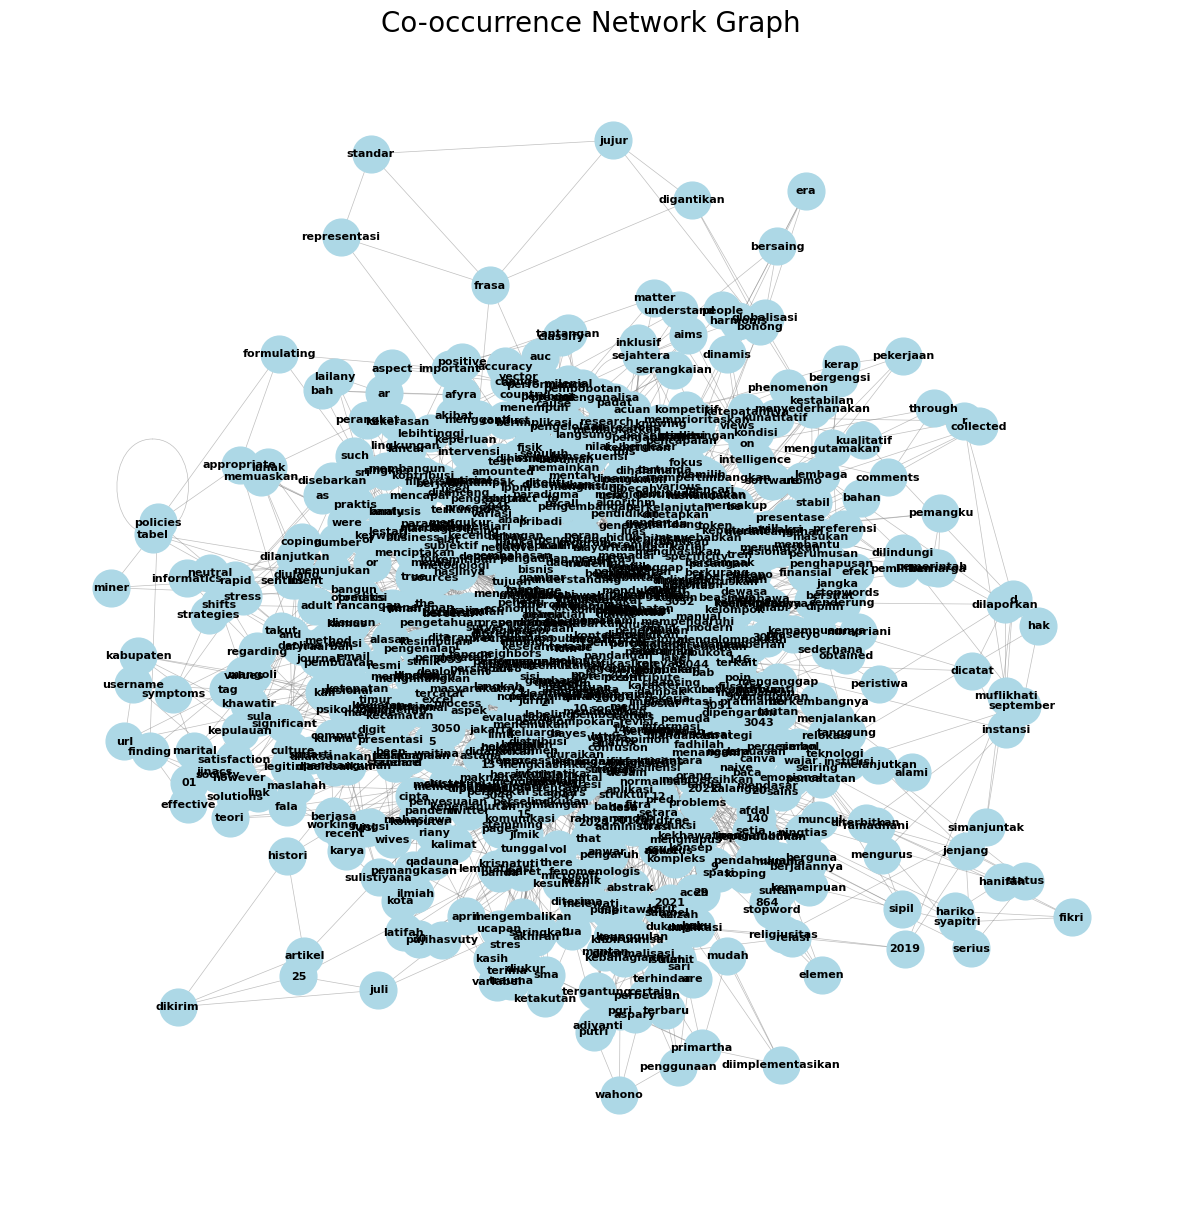

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_adjacency(co_matrix_df)

plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G, k=0.15, iterations=20)
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Co-occurrence Network Graph", size=20)
plt.axis('off')
plt.show()

## 6.Menghitung pagerank setiap node dan tertinggi

In [ ]:
pagerank_scores = nx.pagerank(G)
print("Hasil perhitungan PageRank untuk tiap node:")
for node, score in sorted(pagerank_scores.items(), key=lambda item: item[1], reverse=True)[:10]:
    print(f"{node}: {score:.4f}")

Hasil perhitungan PageRank untuk tiap node:
data: 0.0297
pernikahan: 0.0182
indonesia: 0.0126
sentimen: 0.0126
penelitian: 0.0125
penurunan: 0.0100
jurnal: 0.0097
proses: 0.0087
knn: 0.0081
algoritma: 0.0081


In [ ]:
 import pandas as pd

# 1. Membuat DataFrame pandas dari dictionary pagerank_scores
pagerank_df = pd.DataFrame(list(pagerank_scores.items()), columns=['Kata', 'Skor PageRank'])

# 2. Mengurutkan DataFrame berdasarkan 'Skor PageRank' secara menurun
pagerank_df = pagerank_df.sort_values(by='Skor PageRank', ascending=False)

# 3. Menampilkan 20 kata teratas dari DataFrame yang sudah diurutkan
print("20 kata dengan Skor PageRank tertinggi:")
print(pagerank_df.head(20).reset_index(drop=True))

20 kata dengan Skor PageRank tertinggi:
          Kata  Skor PageRank
0         data       0.029692
1   pernikahan       0.018170
2    indonesia       0.012580
3     sentimen       0.012563
4   penelitian       0.012494
5    penurunan       0.010034
6       jurnal       0.009725
7       proses       0.008735
8          knn       0.008134
9    algoritma       0.008056
10  masyarakat       0.008011
11      sosial       0.007987
12       hasil       0.007395
13    keluarga       0.007075
14           3       0.006719
15       tahap       0.006324
16    analisis       0.005606
17         the       0.005578
18        2024       0.005464
19          in       0.005212


## 7.Visualisasi Network Graph dengan PageRank Coloring

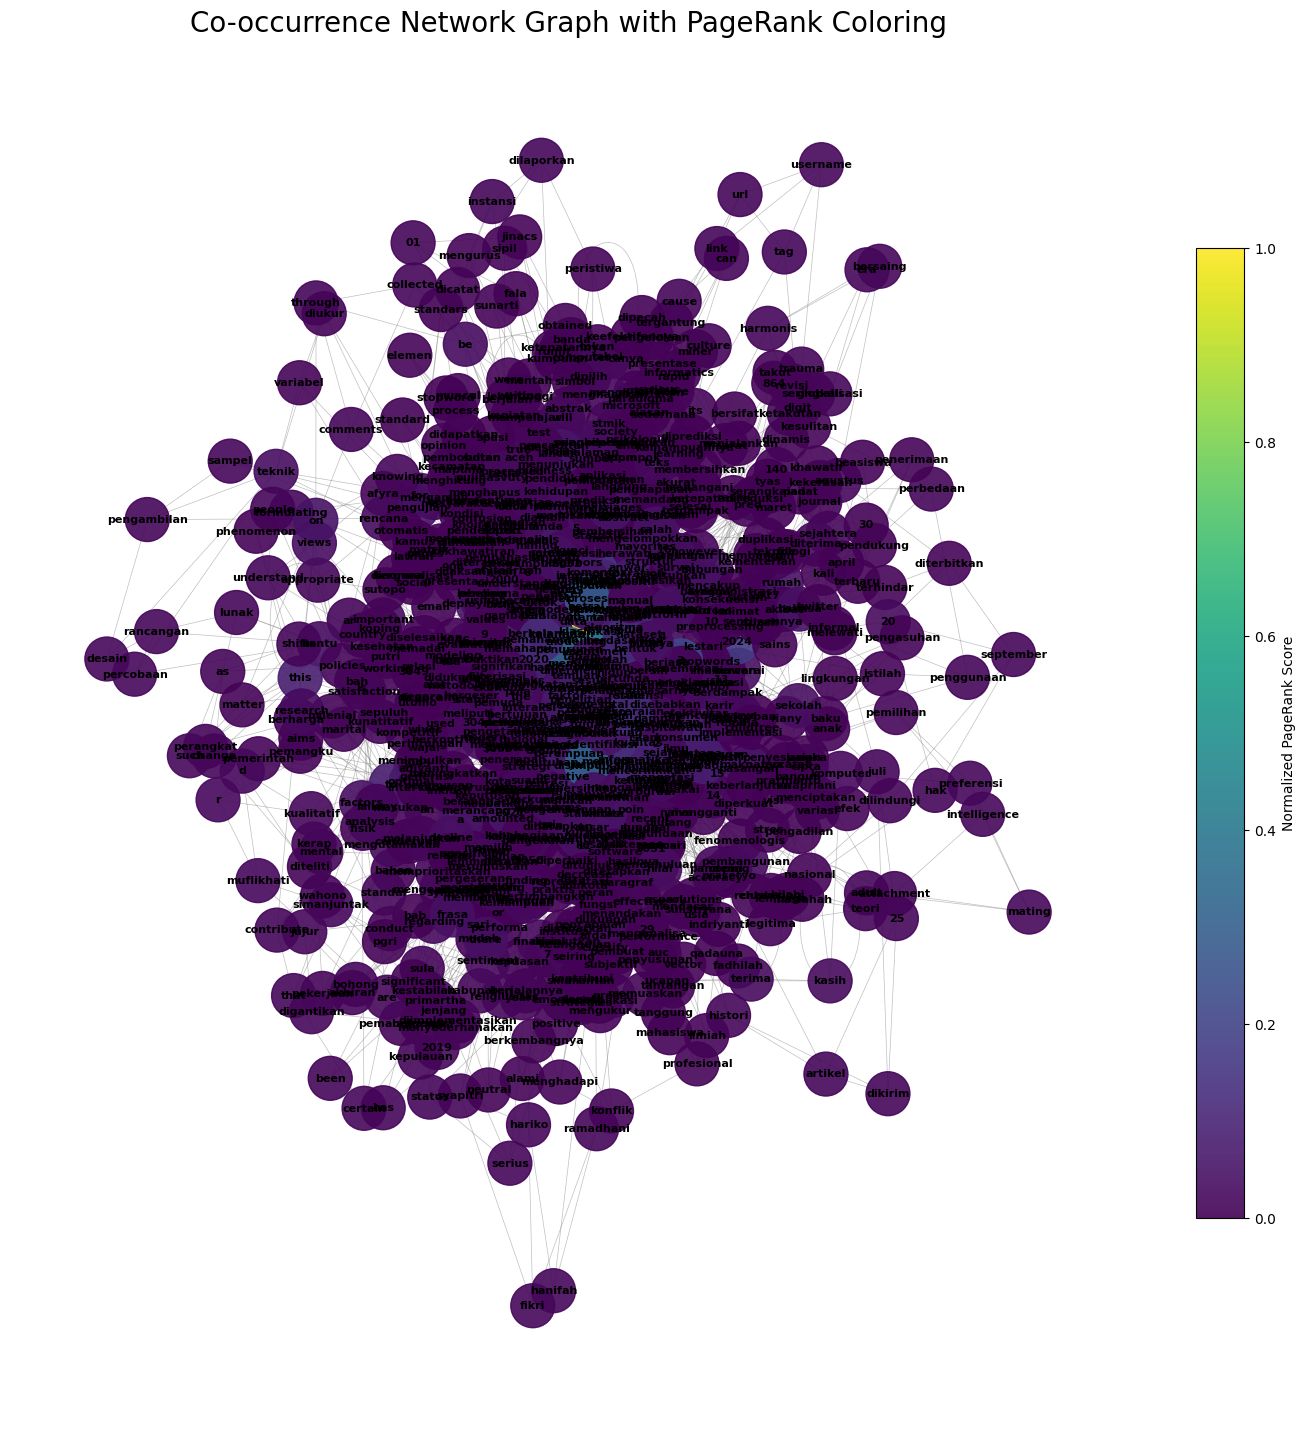

In [ ]:
import numpy as np

pagerank_values = list(pagerank_scores.values())

if len(set(pagerank_values)) > 1:
    scores_norm = (pagerank_values - np.min(pagerank_values)) / (np.max(pagerank_values) - np.min(pagerank_values))
else:
    scores_norm = np.zeros_like(pagerank_values)

node_colors = [scores_norm[list(pagerank_scores.keys()).index(node)] for node in G.nodes()]

plt.figure(figsize=(18, 18))
pos = nx.spring_layout(G, k=0.15, iterations=20)

nodes = nx.draw_networkx_nodes(G, pos, node_size=1000, node_color=node_colors, cmap=plt.cm.viridis, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Co-occurrence Network Graph with PageRank Coloring", size=20)
plt.axis('off')

cbar = plt.colorbar(nodes, shrink=0.7)
cbar.set_label('Normalized PageRank Score')

plt.show()

In [ ]:
print("\n--- Unique Words (Nodes) ---")
print(f"Total unique words (nodes): {len(unique_words)}")
print("First 10 unique words:")
for i, word in enumerate(unique_words[:10]):
    print(f"- {word}")

print("\n--- Graph Edges ---")
print(f"Total edges in the graph: {G.number_of_edges()}")
print("First 10 edges (word co-occurrences):")
for i, edge in enumerate(G.edges()):
    if i >= 10:
        break
    print(f"- {edge[0]} -- {edge[1]}")



--- Unique Words (Nodes) ---
Total unique words (nodes): 820
First 10 unique words:
- nusantara
- melibatkan
- as
- tergantung
- berharga
- peran
- negative
- bercerai
- username
- alami

--- Graph Edges ---
Total edges in the graph: 3496
First 10 edges (word co-occurrences):
- nusantara -- islam
- nusantara -- 4
- nusantara -- algoritma
- nusantara -- ibukota
- nusantara -- naïve
- nusantara -- jurnal
- nusantara -- relokasi
- nusantara -- 1
- melibatkan -- akhiran
- melibatkan -- tahapan


[280 rows x 1 columns] → jumlah total baris awal = 280

Jumlah baris sebelum filter: 280 → sama, 280 baris

Jumlah baris setelah filter: 230 → setelah dibersihkan / filter kalimat kosong atau tidak relevan, tersisa 230 baris
Teks awal: 29321 karakter

Setelah preprocessing: ada 820 kata unik yang dipakai untuk membangun co-occurrence matrix (dan graph network).

In [ ]:
print("Total kata setelah preprocessing:", len(words))
print("Jumlah kata unik:", len(unique_words))

Total kata setelah preprocessing: 2251
Jumlah kata unik: 820


In [ ]:
import pandas as pd

# Misal filtered_df adalah DataFrame setelah filtering baris kosong
# words adalah list kata hasil preprocessing
# unique_words adalah daftar kata unik dari words

# Statistik
jumlah_baris_awal = len(filtered_df)  # sebelum filter
jumlah_baris_setelah_filter = len(filtered_df[filtered_df.iloc[:,0].astype(str).str.strip() != ""])
jumlah_karakter = sum(filtered_df.iloc[:,0].astype(str).apply(len))
total_kata = len(words)
kata_unik = len(unique_words)

# Buat DataFrame ringkasan
summary_df = pd.DataFrame({
    "Statistik": [
        "Jumlah baris awal",
        "Jumlah baris setelah filter",
        "Jumlah karakter teks",
        "Total kata setelah preprocessing",
        "Jumlah kata unik"
    ],
    "Nilai": [
        jumlah_baris_awal,
        jumlah_baris_setelah_filter,
        jumlah_karakter,
        total_kata,
        kata_unik
    ]
})

# Tampilkan tabel ringkasan
display(summary_df)

,Statistik,Nilai
0,Jumlah baris awal,230
1,Jumlah baris setelah filter,230
2,Jumlah karakter teks,29092
3,Total kata setelah preprocessing,2251
4,Jumlah kata unik,820
